## Pulling the Data

In [147]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [148]:
# Imports
import oracledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

In [122]:
# Connecting to our database

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_inigogrc", password="a77155190", dsn=dsn)

In [21]:
# # Inspecting our parent table

# cur = connection.cursor()
# for row in cur.execute("SELECT * FROM parent_table WHERE ROWNUM <= 5"):
#     print(row)
# cur.close()

In [126]:
# Inspecting our parent table
cur = connection.cursor()
cur.execute("SELECT * FROM parent_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
parent_df = pd.DataFrame(rows, columns=col_names)
print(parent_df.info())
parent_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   AGE     43 non-null     int64 
 1   SEX     43 non-null     object
dtypes: int64(1), object(1)
memory usage: 820.0+ bytes
None


,AGE,SEX
0,19,Female
1,19,Male
2,20,Female
3,20,Male
4,21,Female


In [127]:
# Inspecting our social media table
cur = connection.cursor()
cur.execute("SELECT * FROM social_media_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
social_media_df = pd.DataFrame(rows, columns=col_names)
print(social_media_df.info())
social_media_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UNIQUE_ID       613 non-null    int64  
 1   AGE             613 non-null    int64  
 2   SEX             613 non-null    object 
 3   SNS_USE_LENGTH  613 non-null    float64
 4   SNS_USE_DAILY   613 non-null    float64
 5   SNS_USE_CASE    613 non-null    int64  
 6   SNS_FRIENDS     613 non-null    int64  
 7   SNS_PERSONAL    613 non-null    int64  
 8   SNS_CONTENT     613 non-null    object 
 9   SNS_GOOD        613 non-null    int64  
 10  SNS_BELIEVE     613 non-null    int64  
 11  PEER_PRESSURE   613 non-null    int64  
 12  SNS_INFLUENCE   613 non-null    float64
 13  SNS_WELLBEING   613 non-null    int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 67.2+ KB
None


,UNIQUE_ID,AGE,SEX,SNS_USE_LENGTH,SNS_USE_DAILY,SNS_USE_CASE,SNS_FRIENDS,SNS_PERSONAL,SNS_CONTENT,SNS_GOOD,SNS_BELIEVE,PEER_PRESSURE,SNS_INFLUENCE,SNS_WELLBEING
0,1,26,Female,7.5,2.0,12,250,4,To stay connected with people,1,0,0,0.5,0
1,2,24,Female,7.5,6.0,12,1250,4,To stay connected with people,1,0,0,0.5,1
2,3,23,Female,1.0,6.0,22,3000,3,For time pass,1,1,1,0.5,1
3,4,27,Female,7.5,2.0,12,1250,3,For time pass,1,0,1,0.5,0
4,5,19,Male,3.5,4.0,22,1250,2,To make new friends,1,1,0,0.0,0


In [128]:
# Inspecting our social media table
cur = connection.cursor()
cur.execute("SELECT * FROM mental_health_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
mental_health_df = pd.DataFrame(rows, columns=col_names)
print(mental_health_df.info())
mental_health_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIQUE_ID               567 non-null    int64  
 1   AGE                     567 non-null    int64  
 2   SEX                     567 non-null    object 
 3   GENERAL_HEALTH          567 non-null    int64  
 4   PHQ_SCORE               567 non-null    int64  
 5   GAD7_SCORE              567 non-null    int64  
 6   HOPELESS                567 non-null    float64
 7   OVERWHELMED             567 non-null    float64
 8   EXHAUSTED               567 non-null    float64
 9   SAD                     567 non-null    float64
 10  RLY_SAD                 567 non-null    float64
 11  CONSIDERED              567 non-null    float64
 12  ATTEMPTED               567 non-null    float64
 13  DEPRESSION_DIAGNOSIS    567 non-null    int64  
 14  THERAPY                 567 non-null    in

,UNIQUE_ID,AGE,SEX,GENERAL_HEALTH,PHQ_SCORE,GAD7_SCORE,HOPELESS,OVERWHELMED,EXHAUSTED,SAD,RLY_SAD,CONSIDERED,ATTEMPTED,DEPRESSION_DIAGNOSIS,THERAPY,DEPRESSION_MEDICATION,ACHA_12MONTHS_ANY_COMP,STUDENT
0,1,22,Female,4,6,0,0.0,12.5,5.5,3.5,0.0,0.0,0.0,0,0,0,2,1
1,2,21,Female,3,19,4,1.5,5.5,7.5,1.5,1.5,1.5,0.0,0,0,0,0,1
2,3,23,Female,3,10,9,7.5,12.5,12.5,9.5,1.5,0.0,0.0,0,0,0,2,1
3,4,24,Female,3,11,10,9.5,9.5,7.5,12.5,3.5,0.0,0.0,0,0,0,2,1
4,5,22,Female,4,6,18,7.5,3.5,9.5,12.5,1.5,0.0,0.0,0,0,0,5,1


## Conducting Data Analysis

In [168]:
# Query for aggregates
aggregate_query = """
WITH mh_agg AS (
  SELECT 
    age,
    sex,
    COUNT(unique_id) AS mh_count,
    AVG(phq_score) AS avg_phq_score,
    AVG(gad7_score) AS avg_gad7_score,
    AVG(hopeless) AS avg_hopeless,
    AVG(overwhelmed) AS avg_overwhelmed,
    AVG(exhausted) AS avg_exhausted,
    AVG(sad) AS avg_sad,
    AVG(rly_sad) AS avg_rly_sad,
    AVG(considered) AS avg_considered,
    AVG(attempted) AS avg_attempted,
    AVG(depression_diagnosis) AS pct_diagnosed
  FROM mental_health_table
  GROUP BY age, sex
),
sm_agg AS (
  SELECT 
    age,
    sex,
    COUNT(unique_id) AS sm_count,
    AVG(sns_use_length) AS avg_sns_use_length,
    AVG(sns_use_daily) AS avg_sns_use_daily,
    AVG(sns_use_case) AS avg_sns_use_case,
    AVG(sns_friends) AS avg_sns_friends,
    AVG(sns_personal) AS avg_sns_personal,
    AVG(CASE WHEN sns_good = 1 THEN 1 ELSE 0 END) AS pct_sns_good,
    AVG(CASE WHEN sns_believe = 1 THEN 1 ELSE 0 END) AS pct_sns_believe,
    AVG(peer_pressure) AS pct_peer_pressure,
    AVG(sns_influence) AS pct_sns_influence,
    AVG(sns_wellbeing) AS pct_sns_wellbeing
  FROM social_media_table
  GROUP BY age, sex
)
SELECT 
  COALESCE(mh.age, sm.age) AS age,
  COALESCE(mh.sex, sm.sex) AS sex,
  mh.mh_count, sm.sm_count, mh.avg_phq_score, mh.avg_gad7_score, mh.avg_hopeless, 
  mh.avg_overwhelmed, mh.avg_exhausted, mh.avg_sad, mh.avg_rly_sad, mh.avg_considered, 
  mh.avg_attempted, mh.pct_diagnosed, sm.avg_sns_use_length, sm.avg_sns_use_daily,
  sm.avg_sns_use_case, sm.avg_sns_friends, sm.avg_sns_personal, sm.pct_sns_good,
  sm.pct_sns_believe, sm.pct_peer_pressure, sm.pct_sns_influence, sm.pct_sns_wellbeing
FROM mh_agg mh
FULL OUTER JOIN sm_agg sm
  ON mh.age = sm.age
 AND mh.sex = sm.sex
ORDER BY age, sex
"""

cur = connection.cursor()
cur.execute(aggregate_query)

# Fetch rows and columns and create df
rows = cur.fetchall()
col_names = [desc[0] for desc in cur.description]
cur.close()
aggregate_query_df = pd.DataFrame(rows, columns=col_names)
aggregate_query_df

,AGE,SEX,MH_COUNT,SM_COUNT,AVG_PHQ_SCORE,AVG_GAD7_SCORE,AVG_HOPELESS,AVG_OVERWHELMED,AVG_EXHAUSTED,AVG_SAD,AVG_RLY_SAD,AVG_CONSIDERED,AVG_ATTEMPTED,PCT_DIAGNOSED,AVG_SNS_USE_LENGTH,AVG_SNS_USE_DAILY,PCT_SNS_BELIEVE,PCT_PEER_PRESSURE,PCT_SNS_INFLUENCE,PCT_SNS_WELLBEING
0,19,Female,36,14,9.111111,10.000000,5.319444,10.277778,9.833333,7.888889,5.333333,0.930556,0.041667,0.444444,3.357143,3.035714,0.785714,0.714286,0.607143,0.928571
1,19,Male,11,25,8.636364,4.181818,2.818182,5.545455,5.954545,3.545455,1.181818,0.136364,0.000000,0.181818,2.980000,2.880000,0.800000,0.640000,0.380000,0.680000
2,20,Female,57,11,10.561404,7.947368,5.342105,9.324561,8.728070,6.368421,4.412281,1.359649,0.122807,0.368421,3.909091,2.454545,0.272727,0.181818,0.454545,0.727273
3,20,Male,31,23,10.645161,5.741935,4.225806,7.177419,6.822581,5.306452,3.645161,1.387097,0.000000,0.129032,5.195652,3.108696,0.608696,0.739130,0.456522,0.739130
4,21,Female,68,9,10.500000,9.720588,5.779412,9.308824,9.316176,7.007353,5.161765,0.897059,0.022059,0.367647,6.166667,3.388889,0.222222,0.666667,0.444444,0.555556
5,21,Male,36,18,6.666667,7.833333,5.402778,7.750000,6.972222,5.555556,4.055556,1.208333,0.083333,0.277778,4.944444,2.666667,0.555556,0.500000,0.527778,0.444444
6,22,Female,97,23,9.195876,9.536082,6.489691,10.123711,9.932990,8.231959,5.788660,1.510309,0.190722,0.371134,5.304348,4.782609,0.173913,0.434783,0.478261,0.434783
7,22,Male,36,19,8.166667,7.472222,5.305556,8.194444,8.625000,5.763889,4.527778,0.597222,0.041667,0.250000,6.500000,2.815789,0.157895,0.526316,0.394737,0.684211
8,23,Female,37,24,7.189189,8.945946,5.891892,7.581081,7.216216,6.770270,4.959459,0.851351,0.081081,0.351351,5.395833,4.020833,0.333333,0.666667,0.458333,0.666667
9,23,Male,19,29,8.526316,5.789474,4.289474,6.421053,6.973684,6.131579,4.657895,1.657895,0.078947,0.105263,7.689655,3.568966,0.172414,0.517241,0.465517,0.482759


In [171]:
group_by_age = aggregate_query_df.groupby("AGE").mean(numeric_only=True).reset_index()
print("Aggregates by AGE:")
group_by_age

Aggregates by AGE:


,AGE,MH_COUNT,SM_COUNT,AVG_PHQ_SCORE,AVG_GAD7_SCORE,AVG_HOPELESS,AVG_OVERWHELMED,AVG_EXHAUSTED,AVG_SAD,AVG_RLY_SAD,AVG_CONSIDERED,AVG_ATTEMPTED,PCT_DIAGNOSED,AVG_SNS_USE_LENGTH,AVG_SNS_USE_DAILY,PCT_SNS_BELIEVE,PCT_PEER_PRESSURE,PCT_SNS_INFLUENCE,PCT_SNS_WELLBEING
0,19,23.5,19.5,8.873737,7.090909,4.068813,7.911616,7.893939,5.717172,3.257576,0.533460,0.020833,0.313131,3.168571,2.957857,0.792857,0.677143,0.493571,0.804286
1,20,44.0,17.0,10.603282,6.844652,4.783956,8.250990,7.775325,5.837436,4.028721,1.373373,0.061404,0.248727,4.552372,2.781621,0.440711,0.460474,0.455534,0.733202
2,21,52.0,13.5,8.583333,8.776961,5.591095,8.529412,8.144199,6.281454,4.608660,1.052696,0.052696,0.322712,5.555556,3.027778,0.388889,0.583333,0.486111,0.500000
3,22,66.5,21.0,8.681271,8.504152,5.897623,9.159078,9.278995,6.997924,5.158219,1.053766,0.116194,0.310567,5.902174,3.799199,0.165904,0.480549,0.436499,0.559497
4,23,28.0,26.5,7.857752,7.367710,5.090683,7.001067,7.094950,6.450925,4.808677,1.254623,0.080014,0.228307,6.542744,3.794899,0.252874,0.591954,0.461925,0.574713
5,24,14.0,29.5,7.404762,8.142857,5.238095,6.976190,6.547619,5.726190,4.869048,1.095238,0.535714,0.547619,7.094840,3.303416,0.128634,0.416424,0.470930,0.642442
6,25,9.0,48.0,11.208333,6.583333,3.979167,7.354167,6.416667,7.333333,4.437500,0.666667,0.062500,0.291667,7.645455,3.378788,0.153030,0.460606,0.449242,0.596970
7,26,6.5,46.5,11.678571,4.916667,4.654762,7.452381,6.696429,5.875000,3.910714,1.690476,0.000000,0.392857,8.115882,3.157206,0.102059,0.564706,0.435294,0.670882
8,27,4.0,32.5,7.083333,7.583333,6.291667,8.208333,8.083333,7.875000,5.083333,1.833333,0.000000,0.416667,7.615278,3.066667,0.183333,0.597222,0.493056,0.550000
9,28,6.0,16.0,12.444444,7.277778,5.361111,5.972222,7.000000,5.472222,3.777778,1.555556,0.000000,0.666667,7.953125,3.796875,0.156250,0.531250,0.578125,0.687500


In [ ]:
group_by_sex = aggregate_query_df.groupby("AGE").mean(numeric_only=True).reset_index()
print("Aggregates by AGE:")
group_by_s

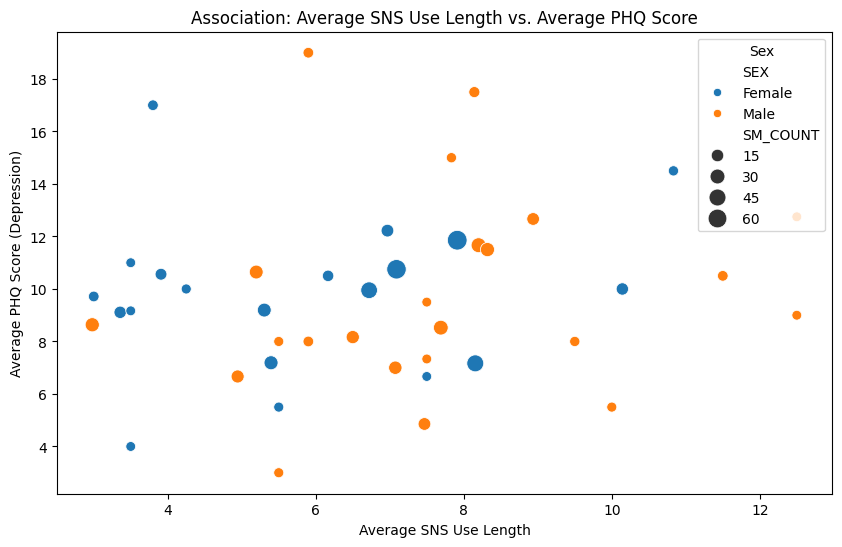

In [151]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=aggregate_query_df, 
                x='AVG_SNS_USE_LENGTH', 
                y='AVG_PHQ_SCORE', 
                hue='SEX', 
                size='SM_COUNT', 
                sizes=(50, 200))
plt.title("Association: Average SNS Use Length vs. Average PHQ Score")
plt.xlabel("Average SNS Use Length")
plt.ylabel("Average PHQ Score (Depression)")
plt.legend(title="Sex")
plt.show()


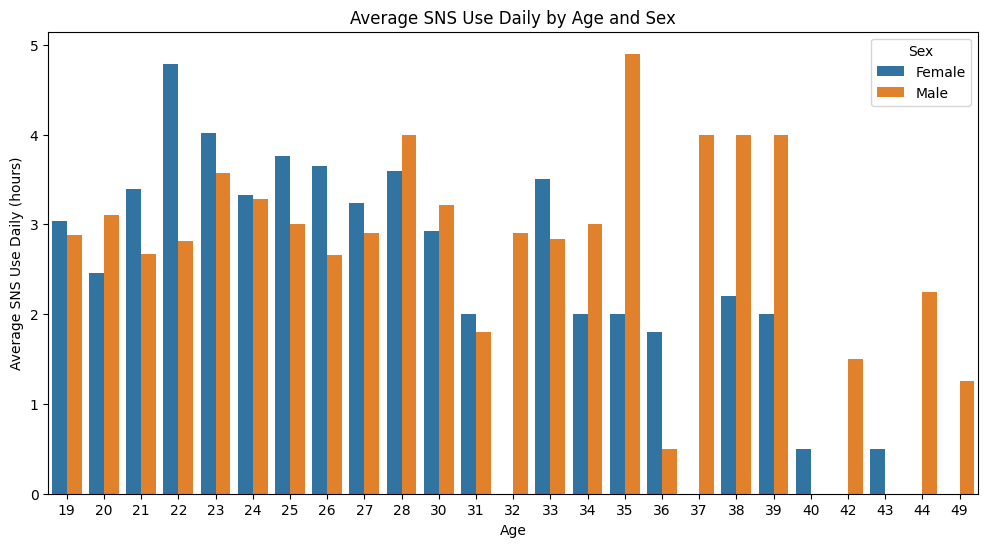

In [153]:
plt.figure(figsize=(12,6))
sns.barplot(data=aggregate_query_df.sort_values("AGE"), 
            x="AGE", 
            y="AVG_SNS_USE_DAILY", 
            hue="SEX")
plt.title("Average SNS Use Daily by Age and Sex")
plt.xlabel("Age")
plt.ylabel("Average SNS Use Daily (hours)")
plt.legend(title="Sex")
plt.show()

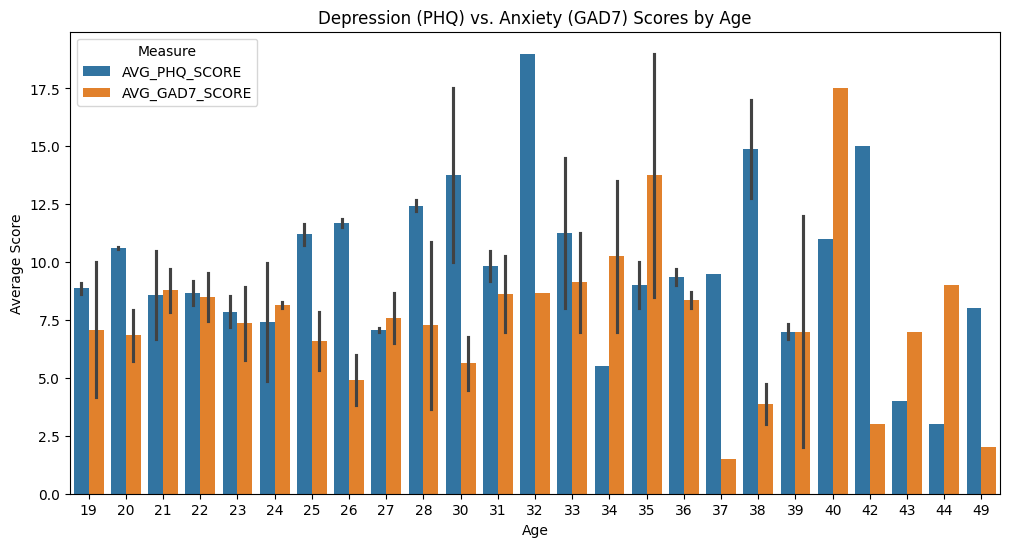

In [154]:
plt.figure(figsize=(12,6))
# Melt the data so that avg_phq_score and avg_gad7_score become two rows per group:
melted = aggregate_query_df.melt(id_vars=['AGE', 'SEX'], 
                          value_vars=['AVG_PHQ_SCORE', 'AVG_GAD7_SCORE'],
                          var_name='MEASURE', value_name='SCORE')

sns.barplot(data=melted, 
            x="AGE", 
            y="SCORE", 
            hue="MEASURE")
plt.title("Depression (PHQ) vs. Anxiety (GAD7) Scores by Age")
plt.xlabel("Age")
plt.ylabel("Average Score")
plt.legend(title="Measure")
plt.show()

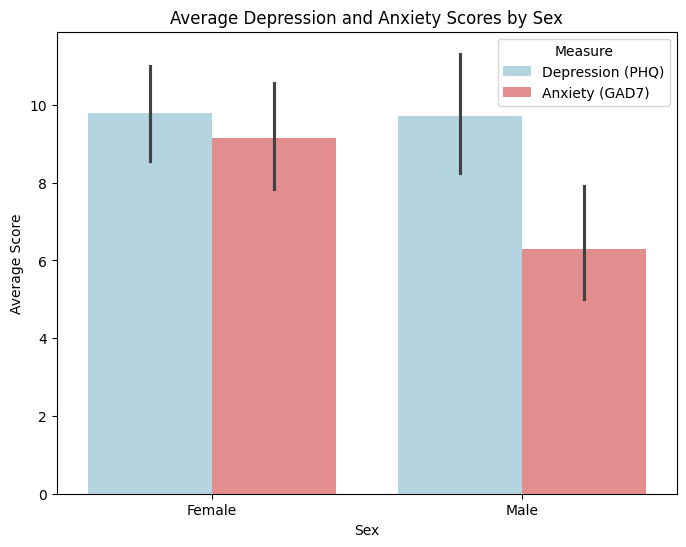

In [160]:
melted_df = aggregate_query_df.melt(
    id_vars=['SEX'],
    value_vars=['AVG_PHQ_SCORE', 'AVG_GAD7_SCORE'],
    var_name='MEASURE',
    value_name='SCORE'
)

palette_dict = {
    "AVG_PHQ_SCORE": "lightblue",
    "AVG_GAD7_SCORE": "lightcoral"
}

plt.figure(figsize=(8,6))

sns.barplot(
    data=melted_df,
    x="SEX",
    y="SCORE",
    hue="MEASURE",
    palette=palette_dict,
    hue_order=["AVG_PHQ_SCORE", "AVG_GAD7_SCORE"] 
)

plt.title("Average Depression and Anxiety Scores by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Score")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Depression (PHQ)", "Anxiety (GAD7)"], title="Measure")
plt.show()

In [ ]:
metrics = ['AVG_SNS_USE_LENGTH','AVG_SNS_USE_DAILY','PCT_SNS_BELIEVE','PCT_PEER_PRESSURE','PCT_SNS_INFLUENCE','PCT_SNS_WELLBEING']
chart_1 = alt.Chart(aggregate_query_df).transform_aggregate(count='count()', groupby=['age','sex','AVG_SNS_USE_LENGTH','AVG_SNS_USE_DAILY','PCT_SNS_BELIEVE','PCT_PEER_PRESSURE','PCT_SNS_INFLUENCE','PCT_SNS_WELLBEING']).mark_point().encode(
    alt.Y(alt.repeat('row'), type = 'quantitative'),
    alt.X('age:Q'),
    alt.Size('count()'),
    # alt.Tooltip([alt.repeat('row'), 'age:Q',])
    ).properties(height = 150).repeat(row=metrics)

In [ ]:
chart_2 = alt.Chart(aggregate_query_df).transform_aggregate(count='count()', groupby=['age','sex','AVG_SNS_USE_LENGTH','AVG_SNS_USE_DAILY','PCT_SNS_BELIEVE','PCT_PEER_PRESSURE','PCT_SNS_INFLUENCE','PCT_SNS_WELLBEING']).mark_point().encode(
    alt.Y(alt.repeat('row'), type = 'quantitative'),
    alt.X('sex:Q'),
    alt.Size('count()'),
    # alt.Tooltip([alt.repeat('row'), 'sex:Q',])
    ).properties(height = 150).repeat(row=metrics)

In [ ]:
metrics = ['AVG_SNS_USE_LENGTH','AVG_SNS_USE_DAILY','PCT_SNS_BELIEVE','PCT_PEER_PRESSURE','PCT_SNS_INFLUENCE','PCT_SNS_WELLBEING']
scores = ['AVG_PHQ_SCORE','AVG_GAD7_SCORE', 'PCT_DIAGNOSED']
chart_1 = alt.Chart(aggregate_query_df).transform_aggregate(count='count()', groupby=['age','sex','AVG_SNS_USE_LENGTH','AVG_SNS_USE_DAILY','PCT_SNS_BELIEVE','PCT_PEER_PRESSURE','PCT_SNS_INFLUENCE','PCT_SNS_WELLBEING']).mark_bar().encode(
    alt.X(alt.repeat('row'), type = 'quantitative'),
    alt.Color('age:Q', legend=None),
    alt.Y(alt.repeat('column', type = 'quantitative')),
    alt.Size('count()')
    # alt.Tooltip([alt.repeat('row'), alt.repeat('column'),])
    ).properties(height = 150).repeat(row=metrics, column=scores)